# Rossmann Store Sales — Forecasting

**EN —** I built this to forecast daily sales for 1,115 Rossmann drugstores six weeks
ahead — the Kaggle competition setup. My priority was to do it *honestly*: no data leakage,
and a real baseline so I can prove the model actually learns something.

**TR —** Bunu 1.115 Rossmann mağazasının günlük satışını 6 hafta ileriye tahmin etmek için
yaptım — Kaggle yarışması kurulumu. Önceliğim işi *dürüst* yapmaktı: veri sızıntısı olmadan
ve modelin gerçekten bir şey öğrendiğini kanıtlayan gerçek bir baseline'la.

**EN — My plan:** clean → EDA → leakage-aware features → time split → baseline vs LightGBM →
Optuna tuning → forecast plots → SHAP → business read-out.

**TR — Planım:** temizlik → EDA → sızıntısız özellikler → zaman bölmesi → baseline vs
LightGBM → Optuna tuning → tahmin grafikleri → SHAP → iş çıkarımı.

> **EN —** I keep the reusable code in `src/`; this notebook is the story.
> **TR —** Tekrar kullanılabilir kodu `src/` altında tutuyorum; bu notebook hikâye.

## 0. Setup / Kurulum
**EN —** I wrote this so it runs both locally and on Colab (on a fresh Colab it clones the repo).
**TR —** Bunu hem yerelde hem Colab'da çalışsın diye yazdım (taze Colab'da repoyu klonlar).

In [ ]:
import sys, os
IN_COLAB = "google.colab" in sys.modules
if not os.path.exists("src") and not os.path.exists("../src"):
    !git clone -q https://github.com/derinteke/rossmann-sales-forecast.git
    %cd rossmann-sales-forecast
sys.path.append("." if os.path.exists("src") else "..")
if IN_COLAB:
    !pip install -q lightgbm optuna shap seaborn

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src import config
from src.data import load_clean
from src.features import build_features, fit_target_encodings, apply_target_encodings, FEATURE_COLS
from src.model import baseline_predict, train_lgbm
from src.evaluate import print_metrics, rmspe
sns.set_theme(style="whitegrid")

## 1. Load & clean / Yükle & temizle
**EN —** I merge `train.csv` with `store.csv`, keep only open days with real sales, and fix
the missing competition/promo fields.
**TR —** `train.csv`'yi `store.csv` ile birleştirip yalnızca açık ve gerçek satışlı günleri
tutuyorum, eksik rakip/promosyon alanlarını düzeltiyorum.

In [3]:
df = load_clean()
print(df.shape, "|", df["Date"].min().date(), "->", df["Date"].max().date())
df[["Store","Date","Sales","Customers","Promo","StoreType"]].head()

(844338, 18) | 2013-01-01 -> 2015-07-31


,Store,Date,Sales,Customers,Promo,StoreType
0,1,2015-07-31,5263,555,1,c
1,2,2015-07-31,6064,625,1,a
2,3,2015-07-31,8314,821,1,a
3,4,2015-07-31,13995,1498,1,c
4,5,2015-07-31,4822,559,1,a


## 2. EDA — is there real signal? / Gerçek sinyal var mı?
**EN —** Before modelling, I checked whether the data even has structure worth learning.
**TR —** Modellemeden önce, verinin öğrenmeye değer bir yapısı var mı diye baktım.

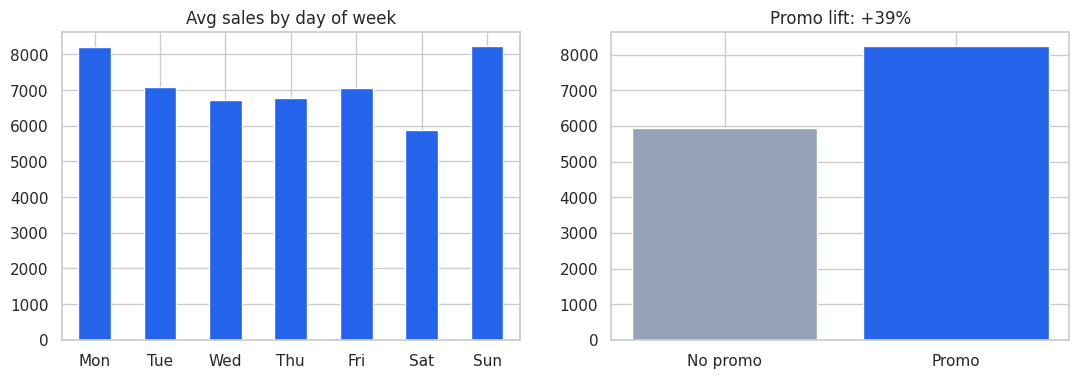

In [4]:
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, ax = plt.subplots(1, 2, figsize=(13,4))
df.groupby("DayOfWeek")["Sales"].mean().plot.bar(ax=ax[0], color="#2563eb")
ax[0].set_xticklabels(days, rotation=0); ax[0].set_title("Avg sales by day of week"); ax[0].set_xlabel("")
m = df.groupby("Promo")["Sales"].mean()
ax[1].bar(["No promo","Promo"], m.values, color=["#94a3b8","#2563eb"])
ax[1].set_title(f"Promo lift: +{m[1]/m[0]-1:.0%}")
plt.show()

**EN —** Good — a clear weekly pattern and a big promo lift. Unlike a synthetic dataset,
these features carry genuine information, which is exactly what I need.
**TR —** Güzel — belirgin bir haftalık desen ve büyük bir promosyon etkisi. Sentetik bir
veriden farklı olarak bu özellikler gerçek bilgi taşıyor, ki tam da ihtiyacım olan bu.

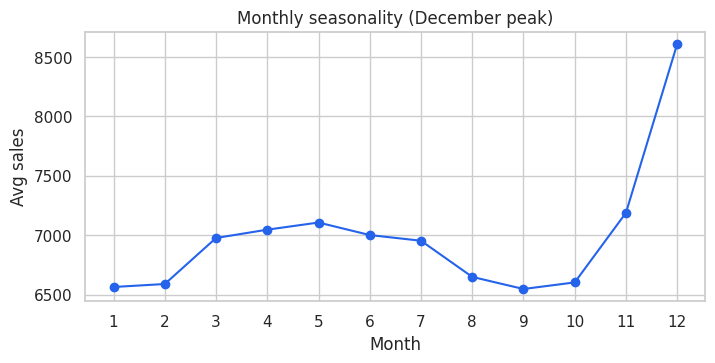

In [5]:
df["Month"] = df["Date"].dt.month
df.groupby("Month")["Sales"].mean().plot(marker="o", figsize=(8,3.5), color="#2563eb")
plt.title("Monthly seasonality (December peak)"); plt.xticks(range(1,13)); plt.ylabel("Avg sales"); plt.show()

## 3. Feature engineering (leakage-aware) / Sızıntısız özellikler
**EN —** Here's a decision I care about: the real task predicts six weeks with *no recent
sales*, so short lags (yesterday's sales) would be leakage. Instead I use things I'd know
ahead of time — calendar, promo, store metadata — plus historical aggregates I fit **only on
the training split** (a store's typical sales by weekday, and under promo vs not). All in
`src/features.py`.

**TR —** Önemsediğim bir karar: gerçek görev *yakın satış olmadan* 6 hafta tahmin etmek, o
yüzden kısa lag'ler (dünün satışı) sızıntı olurdu. Onun yerine önceden bileceğim şeyleri
(takvim, promosyon, mağaza metası) ve **yalnızca eğitim verisinden** fit ettiğim geçmiş
ortalamaları kullanıyorum. Hepsi `src/features.py` içinde.

In [6]:
df = build_features(df)
FEATURE_COLS

['Promo',
 'SchoolHoliday',
 'StateHoliday',
 'IsPromo2Month',
 'Promo2',
 'DayOfWeek',
 'Year',
 'Month',
 'Day',
 'WeekOfYear',
 'DayOfYear',
 'IsWeekend',
 'IsMonthStart',
 'IsMonthEnd',
 'StoreType',
 'Assortment',
 'CompetitionDistanceLog',
 'CompetitionOpenMonths',
 'EncStore',
 'EncStoreDow',
 'EncStorePromo']

## 4. Time-based split / Zaman-bazlı bölme
**EN —** I hold out the last 6 weeks as validation, and I fit the historical encodings on the
training part only — then merge them onto both splits. No peeking.
**TR —** Son 6 haftayı validation'a ayırıyorum ve geçmiş encoding'leri yalnızca eğitim
kısmında fit edip iki bölmeye de birleştiriyorum. Peeking yok.

In [7]:
cutoff = df["Date"].max() - pd.Timedelta(weeks=config.VALIDATION_WEEKS)
train_df = df[df["Date"] <= cutoff].copy()
val_df   = df[df["Date"] >  cutoff].copy()
print(f"cutoff {cutoff.date()} | train {len(train_df):,} | val {len(val_df):,}")
enc = fit_target_encodings(train_df)
train_df = apply_target_encodings(train_df, enc)
val_df   = apply_target_encodings(val_df, enc)
y_val = val_df[config.TARGET].to_numpy()

cutoff 2015-06-19 | train 804,056 | val 40,282


## 5. Baseline vs LightGBM
**EN —** My metric is RMSPE (the competition metric). My baseline is a strong heuristic — a
store's historical median sales for that weekday. Then I train LightGBM (with the tuned
params from `config`, see the next section for how I found them).

**TR —** Metriğim RMSPE (yarışma metriği). Baseline'ım güçlü bir sezgi — mağazanın o gün için
geçmiş medyan satışı. Sonra LightGBM'i (`config`'teki tuned parametrelerle; nasıl bulduğumu
bir sonraki bölümde anlatıyorum) eğitiyorum.

In [8]:
results = {}
results["Baseline"] = print_metrics("Baseline (store x dow)", y_val, baseline_predict(val_df))
model, pred = train_lgbm(train_df, val_df)
results["LightGBM (tuned)"] = print_metrics("LightGBM (tuned)", y_val, pred)
pd.DataFrame(results).T.round(4)

Baseline (store x dow) | RMSPE 0.2451 | RMSE 1696.5 | MAE 1258.8


LightGBM (tuned)       | RMSPE 0.1244 | RMSE 871.0 | MAE 591.2


,RMSPE,RMSE,MAE
Baseline,0.2451,1696.4505,1258.7517
LightGBM (tuned),0.1244,871.0283,591.2057


**EN —** LightGBM roughly halves the baseline error. With my earlier hand-set params this
sat at ~0.128; after the tuning below it's ~0.124. Since it clearly beats a strong naive
baseline, I'm confident it's learning real structure — not echoing the mean.

**TR —** LightGBM baseline hatasını neredeyse yarıya indiriyor. Önceki elle ayarlı
parametrelerimle ~0.128'deydi; aşağıdaki tuning'den sonra ~0.124. Naif baseline'ı açık ara
geçtiği için gerçek yapı öğrendiğine güveniyorum — ortalamayı tekrarlamıyor.

## 6. Tuning with Optuna — without peeking / Peeking'siz Optuna tuning
**EN —** This is the part I'm most careful about. To tune honestly I refused to look at the
final validation window. I tuned on the 6 weeks *before* it, and I picked the number of trees
with a separate inner split — so the real hold-out stayed untouched until one final
measurement. The full, resumable search lives in `src/tune.py`; below I run a tiny 3-trial
demo just to show the machinery.

**TR —** En dikkat ettiğim kısım bu. Dürüst tune etmek için final validation penceresine
bakmayı reddettim. Ondan *önceki* 6 haftada tune ettim ve ağaç sayısını ayrı bir iç bölmeyle
seçtim — böylece gerçek hold-out tek bir final ölçüme kadar el değmemiş kaldı. Tam ve resume
edilebilir arama `src/tune.py` içinde; aşağıda mekanizmayı göstermek için minik 3-deneme
demosu koşuyorum.

**EN —** The heart of the search is this objective (full version in `src/tune.py`). I run
it live from the command line — `python -m src.tune --trials 15` — rather than in the notebook,
so nobody has to wait for Optuna on every run:

**TR —** Aramanın kalbi bu objective (tam hâli `src/tune.py`'de). Bunu notebook yerine komut
satırından çalıştırıyorum — `python -m src.tune --trials 15` — ki her açılışta kimse Optuna'yı
beklemesin:

```python
def objective(trial):
    params = {
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.09, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 63, 800),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    # train on the EARLIER window, early-stop + score on the tune-val window (never real-val)
    model = lgb.train(params, dtrain, num_boost_round=1500, valid_sets=[dvalid],
                      callbacks=[lgb.early_stopping(50)])
    return rmspe(yva, predict(model))   # minimise RMSPE
```

In [9]:
# The params my 28-trial search landed on — already saved into config and used above:
config.LGBM_PARAMS

{'n_estimators': 697,
 'learning_rate': 0.06841,
 'num_leaves': 582,
 'min_child_samples': 36,
 'subsample': 0.9371,
 'subsample_freq': 1,
 'colsample_bytree': 0.5595,
 'reg_alpha': 0.006472,
 'reg_lambda': 0.03485}

**EN —** My real 28-trial search moved the tune-window RMSPE from ~0.131 to ~0.124, and on
the untouched real hold-out the tuned model landed at **0.124** vs **0.128** before — a small
but honest gain. On a model already near the dataset's ceiling, that's about what I'd expect.

**TR —** Gerçek 28-denemelik aramam tune-penceresi RMSPE'sini ~0.131'den ~0.124'e getirdi ve
dokunulmamış gerçek hold-out'ta tuned model **0.124** (önce **0.128**) çıktı — küçük ama
dürüst bir kazanç. Verinin tavanına zaten yakın bir modelde beklediğim de buydu.

## 7. Forecast plots / Tahmin grafikleri

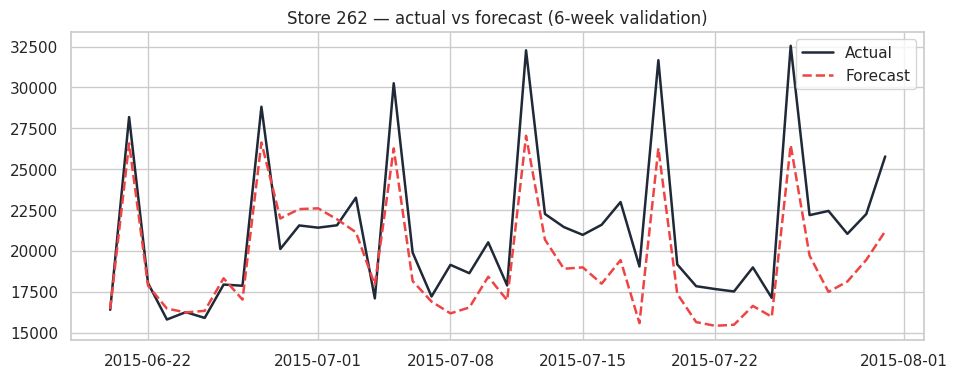

In [10]:
v = val_df.copy(); v["Pred"] = pred
s = v[v["Store"]==262].sort_values("Date")
plt.figure(figsize=(11,4))
plt.plot(s["Date"], s["Sales"], label="Actual", color="#1f2937", lw=1.8)
plt.plot(s["Date"], s["Pred"], label="Forecast", color="#ef4444", ls="--", lw=1.8)
plt.title("Store 262 — actual vs forecast (6-week validation)"); plt.legend(); plt.show()

## 8. Explainability (SHAP)
**EN —** I used SHAP to see what the model leans on — so I can trust it and explain it.
**TR —** Modelin neye dayandığını görmek için SHAP kullandım — böylece hem güvenip hem
açıklayabiliyorum.

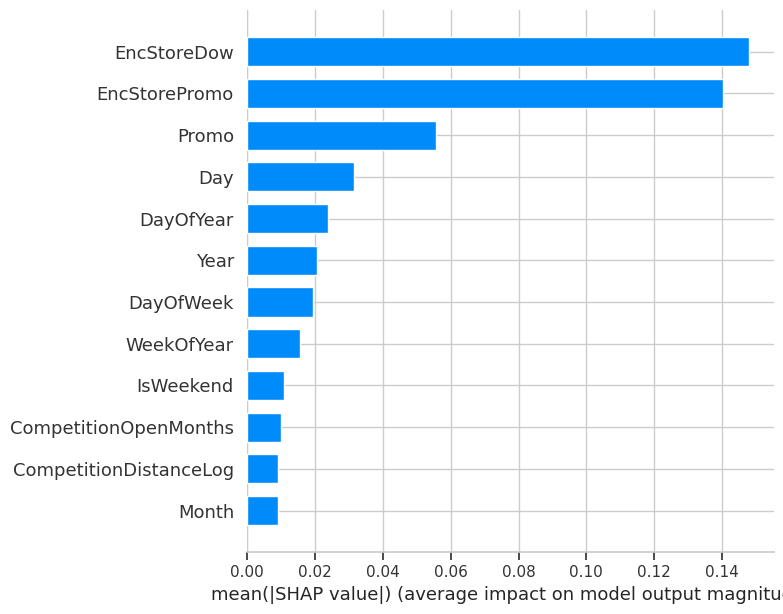

In [11]:
import shap
cat = ["StoreType","Assortment","StateHoliday","DayOfWeek"]
X = train_df[FEATURE_COLS].sample(1000, random_state=0).copy()
for c in cat: X[c] = X[c].astype("category")
sv = shap.TreeExplainer(model).shap_values(X)
shap.summary_plot(sv, X, plot_type="bar", max_display=12)

**EN —** The store's own history (typical sales by weekday and under promo) dominates,
then the promo flag and calendar. This lines up with the EDA and makes business sense.
**TR —** Mağazanın kendi geçmişi (gün bazında ve promosyonlu tipik satış) baskın, ardından
promosyon ve takvim geliyor. Bu, EDA ile örtüşüyor ve iş açısından mantıklı.

## 9. Business read-out & what I learned / İş çıkarımı & öğrendiklerim

**EN / TR:**
| Finding / Bulgu | So what / Ne işe yarar |
|---|---|
| Promo lifts sales ~+39% / Promosyon ~+%39 | Quantify promo ROI, plan the promo calendar / Promosyon ROI'sini ölç, takvimi planla |
| Strong weekly cycle / Güçlü haftalık döngü | Staff & stock to the day-of-week curve / Vardiya & stoğu güne göre ayarla |
| December peak / Aralık zirvesi | Pre-build inventory for Christmas / Yılbaşı için stok hazırla |
| Tuned RMSPE ~0.124 vs 0.245 baseline | A deployable 6-week per-store forecast / Yayına hazır mağaza bazlı 6-haftalık tahmin |

**EN — What I took away:** framing matters more than model choice. I set this up as a true
six-week-ahead forecast, avoided leaky lags on purpose, tuned without peeking, and always
compared against a naive baseline. The model beats that baseline by ~2×, which is my honest
proof the signal is real. Next I'd add per-store prediction intervals and ship it as a small
API + dashboard.

**TR — Çıkardığım ders:** çerçeveleme, model seçiminden daha önemli. Bunu gerçek bir 6-hafta
ileri tahmin olarak kurdum, sızıntılı lag'lerden bilerek kaçındım, peeking yapmadan tune ettim
ve hep naif baseline'la kıyasladım. Model o baseline'ı ~2× geçiyor — sinyalin gerçek olduğuna
dair dürüst kanıtım bu. Sıradaki adım: mağaza bazlı tahmin aralıkları ve küçük bir API +
panel olarak yayınlamak.